In [10]:
import pandas as pd
import matplotlib as plot
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("mimic-code/mimic-iv-demo/2.2/hosp/patients.csv", sep=",")

paciente = df[["subject_id","gender","anchor_age"]]
paciente["Morreu"] = df["dod"].notna().astype(int)

print(paciente)

paciente

contagem = paciente["gender"].value_counts()

plt.figure(figsize=(6,4))
contagem.plot(kind='bar', color=['blue', 'pink'])
plt.xlabel("Gênero")
plt.ylabel("Quantidade")
plt.title("Distribuição de Gênero dos Pacientes")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

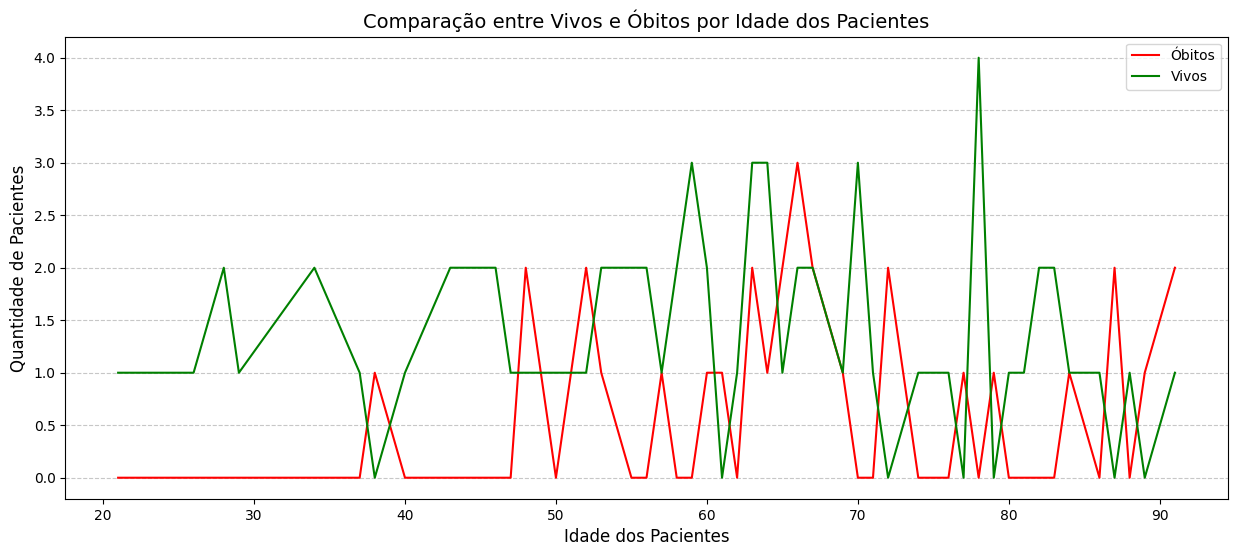

In [66]:
import matplotlib.pyplot as plt
import pandas as pd

# Agrupar os dados por idade
idade = paciente["anchor_age"]
morte = paciente["Morreu"]

# Criar um DataFrame com a contagem de óbitos para cada idade
contagem_por_idade = pd.DataFrame({
    "Idade": idade,
    "Morreu": morte
})

# Contar as mortes para cada idade
mortes_por_idade = contagem_por_idade.groupby("Idade").agg({"Morreu": "sum"}).reset_index()

# Contar a quantidade total de pacientes para cada idade (independente de óbito)
total_por_idade = contagem_por_idade.groupby("Idade").size().reset_index(name="Total")

# Merge as duas tabelas (total de pacientes e mortes por idade)
dados_completos = pd.merge(total_por_idade, mortes_por_idade, on="Idade", how="left")
dados_completos["Vivos"] = dados_completos["Total"] - dados_completos["Morreu"]

# Plotar o gráfico de linha
plt.figure(figsize=(15,6))

# Plotar linha para óbitos (em vermelho)
plt.plot(dados_completos["Idade"], dados_completos["Morreu"], label="Óbitos", color='red')

# Plotar linha para vivos (em verde)
plt.plot(dados_completos["Idade"], dados_completos["Vivos"], label="Vivos", color='green')

# Configurações do gráfico
plt.xlabel("Idade dos Pacientes", fontsize=12)
plt.ylabel("Quantidade de Pacientes", fontsize=12)
plt.title("Comparação entre Vivos e Óbitos por Idade dos Pacientes", fontsize=14)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibir gráfico
plt.show()


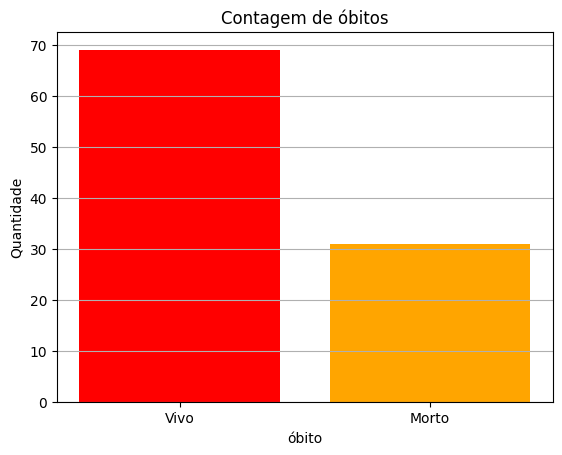

In [56]:


contagem = paciente["Morreu"].value_counts()

plt.bar(
    contagem.index,
    contagem.values,
    color=['red','orange'],
    label="Óbitos"
)
plt.xticks(ticks=[0,1],labels=["Vivo","Morto"])
plt.xlabel("óbito")
plt.ylabel("Quantidade")
plt.title("Contagem de óbitos")
plt.grid(axis='y',linestyle='-')
plt.show()


/tmp/ipykernel_6245/2282023275.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  admissoes ["num Idas"] = admissoes.groupby("subject_id")["subject_id"].transform("count")


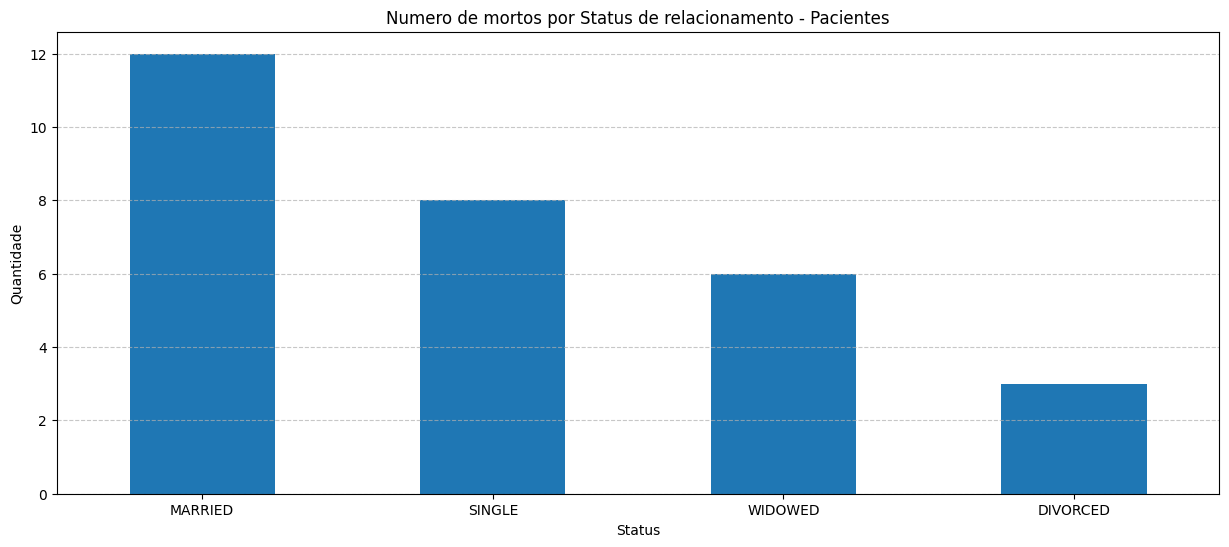

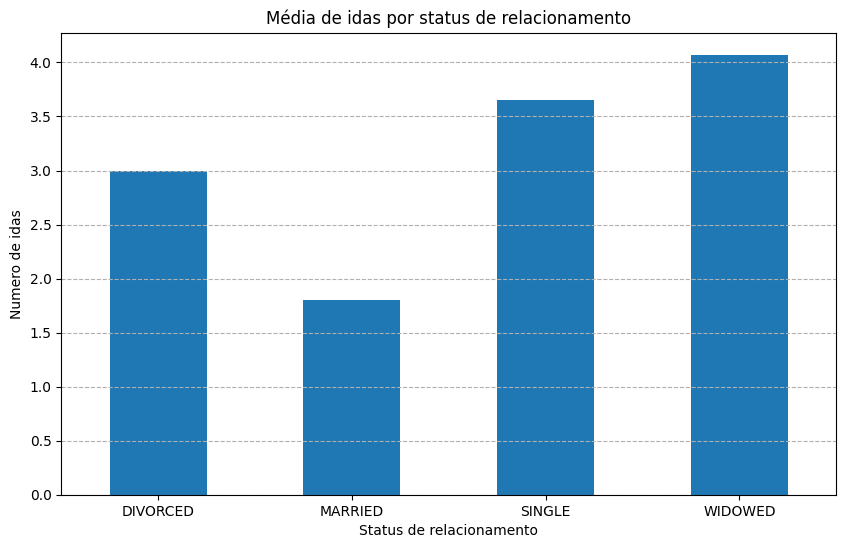

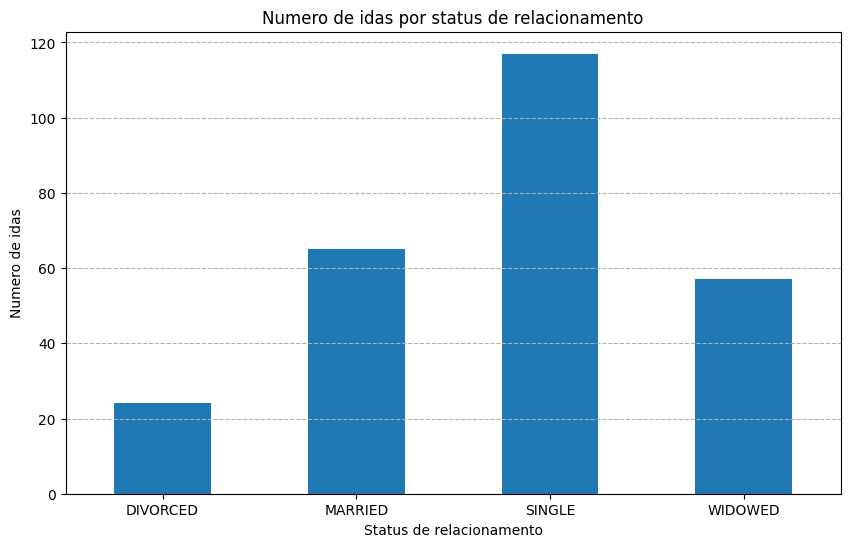

Numero médio de idas: 2.75
[10003400 10032725 10027445 10040025 10020640 10019003 10002930 10010471
 10031757 10000032 10038081 10035631 10024043 10021666 10025463 10017492
 10021938 10026255 10023117 10018081 10037975 10004720 10037861 10007818
 10018845 10020944 10005866 10019777 10005817 10015931 10006053]
31
Total de casados: 36
Casados que morreram: 12
Porcentagem de mortos entre casados: 33.33%
Porcentagem de mortos total: 38.71%


In [200]:
ff = pd.read_csv("mimic-code/mimic-iv-demo/2.2/hosp/admissions.csv", sep=",")

admissoes = ff[["subject_id","insurance","language","marital_status","race"]]


admissoes ["num Idas"] = admissoes.groupby("subject_id")["subject_id"].transform("count")

admissoes = admissoes.drop_duplicates(subset="subject_id")

resultado = pd.merge(paciente,admissoes,on="subject_id",how="inner")

#print(resultado.head())


media = resultado["num Idas"].mean()

filtro43 = resultado[resultado["Morreu"]==1]
relacionamentos = filtro43["marital_status"].value_counts()

plt.figure(figsize=(15,6))
relacionamentos.plot(kind='bar')
plt.xlabel("Status")
plt.ylabel("Quantidade")
plt.title("Numero de mortos por Status de relacionamento - Pacientes")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


idas = resultado.groupby("marital_status")["num Idas"].mean()

plt.figure(figsize=(10,6))

idas.plot(kind='bar')
plt.xlabel("Status de relacionamento")
plt.ylabel("Numero de idas")
plt.title("Média de idas por status de relacionamento")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle="--")
plt.show()

sum_idas = resultado.groupby("marital_status")["num Idas"].sum()

plt.figure(figsize=(10,6))

sum_idas.plot(kind='bar')
plt.xlabel("Status de relacionamento")
plt.ylabel("Numero de idas")
plt.title("Numero de idas por status de relacionamento")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle="--")
plt.show()

print(f"Numero médio de idas: {media}")

mortos = resultado[resultado["Morreu"]==1]

print(mortos["subject_id"].unique())
mortos0 = mortos.shape[0]

print(mortos0)

casados = resultado[resultado["marital_status"] == 'MARRIED']
casados_d = casados[casados["Morreu"] == 1]

total_casados = casados.shape[0]

total_mortos_casados = casados_d.shape[0]

porcentagem_mortos = (total_mortos_casados / total_casados) * 100 if total_casados > 0 else 0
porcentagem_mortos_total = (total_mortos_casados/mortos0) * 100

print(f"Total de casados: {total_casados}")
print(f"Casados que morreram: {total_mortos_casados}")
print(f"Porcentagem de mortos entre casados: {porcentagem_mortos:.2f}%")
print(f"Porcentagem de mortos total: {porcentagem_mortos_total:.2f}%")



In [231]:
items  = [x.lower() for x in ["vasopressin", "Phenylephrine","Epinephrine", "Norepinephrine", "Dopamine",
         "Angiotensin II","dobutamine","milrinone"]]



med = pd.read_csv("mimic-code/mimic-iv-demo/2.2/icu/d_items.csv")
eventos = pd.read_csv("mimic-code/mimic-iv-demo/2.2/hosp/emar.csv")

eventos["medication"] = eventos["medication"].str.lower()
med["label"] = med["label"].str.lower()

filtro = med[["itemid","label"]]
item = filtro[filtro["label"].isin(items)].reset_index(drop=True) #isin é tipo um filtro na coluna que eu passar


filtro2 = eventos[["subject_id","medication", "hadm_id"]]

tem = filtro2[filtro2["medication"].isin(item["label"])].reset_index(drop=True)

contagem = tem["medication"].value_counts()
item["Quantidade"] = item["label"].map(contagem).fillna(0).astype(int)

print(item)


   itemid           label  Quantidade
0  221662        dopamine          22
1  222315     vasopressin          48
2  221653      dobutamine          40
3  221906  norepinephrine         218
4  221289     epinephrine          14
5  221749   phenylephrine         115
6  221986       milrinone          16


(35,)
(65,)
[10003400 10027445 10040025 10019003 10002930 10010471 10031757 10000032
 10038081 10035631 10017492 10023117 10018081 10004720 10037861 10007818
 10020944 10005866 10019777 10005817 10015931]


/tmp/ipykernel_6245/3759438829.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mortoos["medication"] = mortoos["medication"].str.lower()


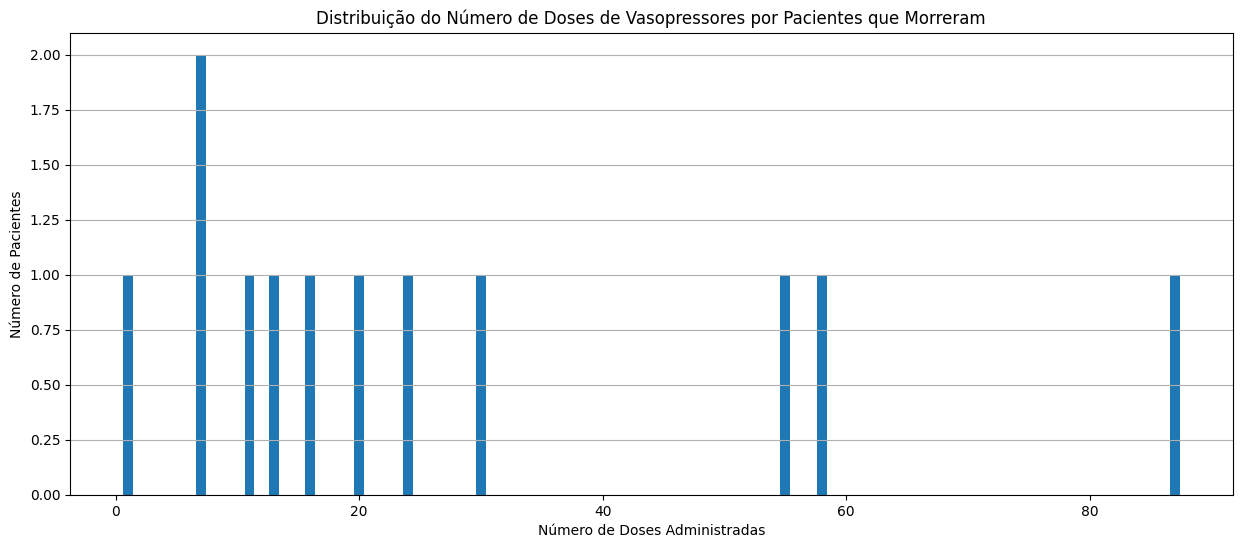

Mortos: total_doses
1     1
7     2
11    1
13    1
16    1
20    1
24    1
30    1
55    1
58    1
87    1
Name: count, dtype: int64 Doses: [1 2 1 1 1 1 1 1 1 1 1]


In [232]:
# Mesclar os dados
inferencia = pd.merge(paciente, filtro2, on="subject_id", how="inner")

testess = pd.merge(paciente,filtro2, on="subject_id",how='outer',indicator=True)
sem_medicacao = testess[testess["_merge"]=="left_only"]["subject_id"].reset_index(drop=True)

print(sem_medicacao.shape)
print(eventos["subject_id"].unique().shape)
# Filtrar apenas os pacientes que morreram
mortoos = inferencia[inferencia["Morreu"] == 1]

print(mortoos["subject_id"].unique())

mortoos["medication"] = mortoos["medication"].str.lower()
item["label"] = item["label"].str.lower()


# Filtrar apenas os medicamentos desejados
ocorrencia = mortoos[mortoos["medication"].isin(item["label"])].reset_index(drop=True)

# Contar o número total de doses administradas por paciente
quantas = ocorrencia.groupby("subject_id")["medication"].count().reset_index()
quantas.rename(columns={"medication": "total_doses"}, inplace=True)

# Contar quantos pacientes receberam cada quantidade de doses
doses_vs_pacientes = quantas["total_doses"].value_counts().sort_index()

# Plotando o gráfico
plt.figure(figsize=(15,6))
plt.bar(doses_vs_pacientes.index, doses_vs_pacientes.values)
plt.xlabel("Número de Doses Administradas")
plt.ylabel("Número de Pacientes")
plt.title("Distribuição do Número de Doses de Vasopressores por Pacientes que Morreram")
plt.grid(axis='y')

plt.show()

print(f"Mortos: {doses_vs_pacientes} Doses: {doses_vs_pacientes.values}")


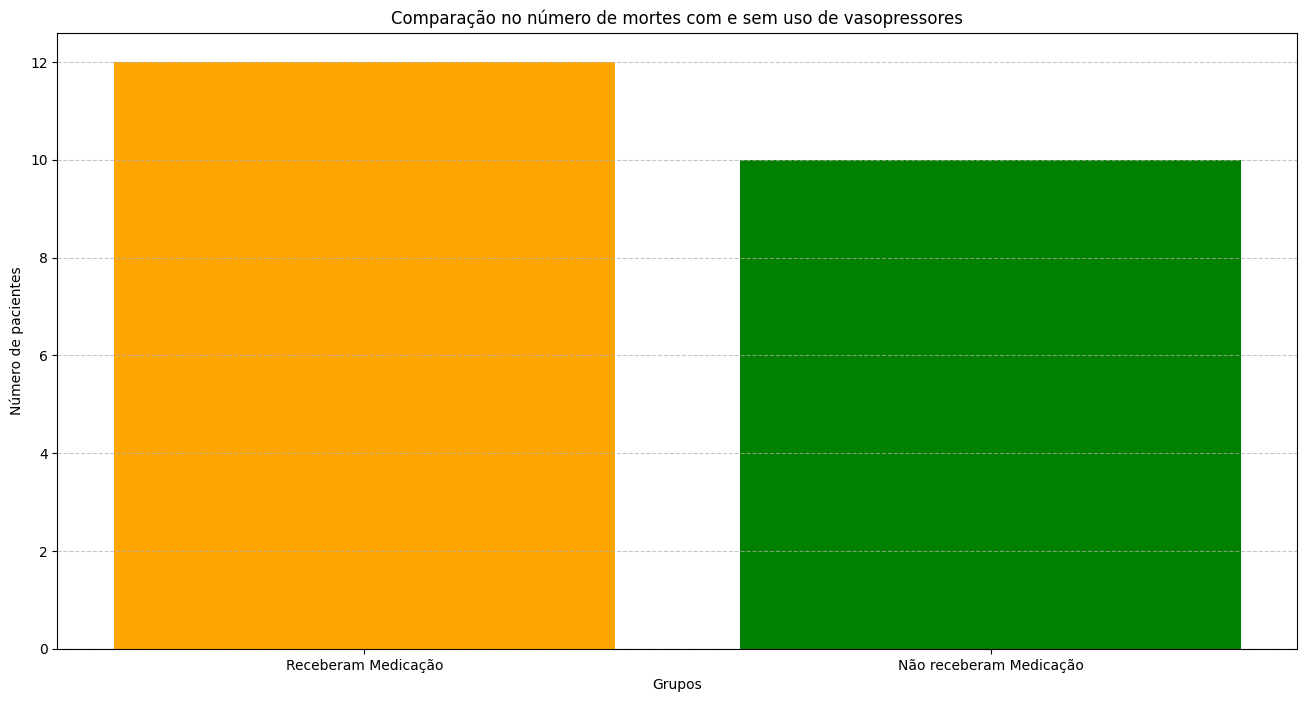

In [233]:
morreu_1 = inferencia[inferencia["Morreu"]==1].copy()
morreu_2 = paciente[paciente["Morreu"]==1].copy()
morreu_com = morreu_1[morreu_1["medication"].isin(item["label"])].reset_index(drop=True)

krl = paciente[paciente["Morreu"]==1]

#print(krl.shape)

morreu_com = morreu_com.drop_duplicates(subset="subject_id").reset_index(drop=True)
morreu_sem = morreu_2[morreu_2["subject_id"].isin(sem_medicacao)].reset_index(drop=True)

num_morreu_com = morreu_com["subject_id"].nunique()
num_morreu_sem = morreu_sem["subject_id"].nunique()

data = pd.DataFrame({
    "Grupo":["Receberam Medicação", "Não receberam Medicação"],
    "Pacientes": [num_morreu_com,num_morreu_sem]
})

plt.figure(figsize=(16,8))

plt.bar(data["Grupo"], data["Pacientes"],color=["orange","green"])

plt.xlabel("Grupos")
plt.ylabel("Número de pacientes")
plt.title("Comparação no número de mortes com e sem uso de vasopressores")
plt.grid(axis='y',linestyle="--", alpha=0.7)

plt.show()




In [ ]:
import pandas as pd
import scipy.stats as stats

# Criar tabela de contingência: [Casado x Não Casado] vs [Sobreviveu x Morreu]
tabela = pd.crosstab(resultado["marital_status"] == "MARRIED", resultado["Morreu"])

# Aplicar teste qui-quadrado
chi2, p_valor, _, _ = stats.chi2_contingency(tabela)

print(f"Teste Qui-Quadrado:")
print(f"Estatística X²: {chi2:.4f}")
print(f"Valor-p: {p_valor:.4f}")

# Interpretação
if p_valor < 0.05:
    print("Há evidências estatíst   icas de que o status de relacionamento influencia a mortalidade.")
else:
    print("Não há evidências suficientes para afirmar que o status de relacionamento influencia a mortalidade.")


Teste Qui-Quadrado:
Estatística X²: 0.0235
Valor-p: 0.8783
Não há evidências suficientes para afirmar que o status de relacionamento influencia a mortalidade.


In [138]:
# Filtrar dados
num_idas_casados = resultado[resultado["marital_status"] == "MARRIED"]["num Idas"]
num_idas_nao_casados = resultado[resultado["marital_status"] != "MARRIED"]["num Idas"]

# Teste t
t_stat, p_valor = stats.ttest_ind(num_idas_casados, num_idas_nao_casados, equal_var=False)

print(f"Teste t de Student:")
print(f"Estatística t: {t_stat:.4f}")
print(f"Valor-p: {p_valor:.4f}")

# Interpretação
if p_valor < 0.05:
    print("Há uma diferença estatisticamente significativa no número de idas ao hospital entre casados e não casados.")
else:
    print("Não há evidências suficientes para afirmar que casados e não casados possuem um número diferente de idas ao hospital.")


Teste t de Student:
Estatística t: -2.7346
Valor-p: 0.0074
Há uma diferença estatisticamente significativa no número de idas ao hospital entre casados e não casados.


In [ ]:
import seaborn as sns
 
plt.figure(figsize=(8,6))
sns.boxplot(x=resultado["marital_status"] == "MARRIED", y=resultado["num Idas"], palette=["red", "blue"])
plt.xticks(ticks=[0, 1], labels=["Não Casados", "Casados"])
plt.xlabel("Estado Civil")
plt.ylabel("Número de Idas ao Hospital")
plt.title("Distribuição de Idas ao Hospital por Status de Relacionamento")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()
    

c = 'c = %r; print(c %% c)'; print(c % c)
